In [8]:
!pip install transformers datasets tokenizers scikit-learn

In [9]:
import time
import torch
import numpy as np
from datasets import load_dataset
from transformers import (
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import accuracy_score, f1_score
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

In [10]:
dataset = load_dataset("glue", "sst2")

train_data = dataset["train"]
val_data = dataset["validation"]

In [11]:
def train_bpe_tokenizer(texts):
    tokenizer = Tokenizer(BPE())
    tokenizer.pre_tokenizer = Whitespace()

    trainer = BpeTrainer(vocab_size=30000)

    tokenizer.train_from_iterator(texts, trainer)

    return tokenizer

bpe_tokenizer = train_bpe_tokenizer(train_data["sentence"])

In [12]:
def char_tokenizer(text):
    return list(text)

In [13]:
MAX_LEN = 128
all_text = "".join(train_data["sentence"])
char_vocab = {c: i+1 for i, c in enumerate(set(all_text))}

def encode_bpe(example):
    enc = bpe_tokenizer.encode(example["sentence"])
    ids = enc.ids[:MAX_LEN]

    padding = [0] * (MAX_LEN - len(ids))

    return {
        "input_ids": ids + padding,
        "attention_mask": [1]*len(ids) + padding,
        "labels": example["label"]
    }

def encode_char(example):
    tokens = list(example["sentence"])

    ids = [char_vocab.get(c, 0) for c in tokens][:MAX_LEN]
    padding = [0] * (MAX_LEN - len(ids))

    return {
        "input_ids": ids + padding,
        "attention_mask": [1]*len(ids) + padding,
        "labels": example["label"]
    }

In [14]:
bpe_train = train_data.map(encode_bpe)
bpe_val = val_data.map(encode_bpe)

char_train = train_data.map(encode_char, num_proc=4)
char_val = val_data.map(encode_char)

bpe_train.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
bpe_val.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

char_train.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
char_val.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map (num_proc=4):   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1
    }

In [18]:
def train_model(train_ds, val_ds, name):
    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    )

    args = TrainingArguments(
        output_dir=f"./{name}",
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,
        logging_steps=100,
        do_eval=True,
        save_strategy="no"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics
    )

    start = time.time()
    trainer.train()
    end = time.time()

    metrics = trainer.evaluate()

    model_size = sum(p.numel() for p in model.parameters()) * 4 / (1024**2)

    print(f"\n{name} RESULTS:")
    print("Accuracy:", metrics["eval_accuracy"])
    print("F1 Score:", metrics["eval_f1"])
    print("Training Time:", end - start)
    print("Model Size (MB):", model_size)

    return metrics

In [19]:
bpe_results = train_model(bpe_train, bpe_val, "BPE")
char_results = train_model(char_train, char_val, "CHAR")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.715599
200,0.696401
300,0.698475
400,0.696315
500,0.693168
600,0.708566
700,0.701097
800,0.701438
900,0.693911
1000,0.691503



BPE RESULTS:
Accuracy: 0.5091743119266054
F1 Score: 0.6747720364741642
Training Time: 1782.8453307151794
Model Size (MB): 417.64746856689453


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.706781
200,0.702911
300,0.690569
400,0.693228
500,0.695013
600,0.697748
700,0.697611
800,0.692447
900,0.687201
1000,0.690142



CHAR RESULTS:
Accuracy: 0.5091743119266054
F1 Score: 0.6747720364741642
Training Time: 1851.098207950592
Model Size (MB): 417.64746856689453


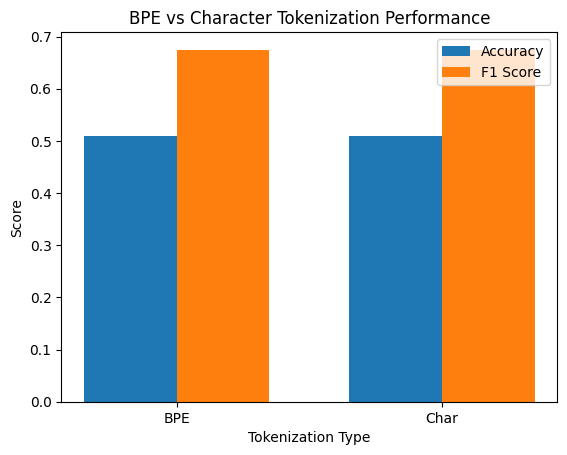

In [24]:
import matplotlib.pyplot as plt
import numpy as np

models = ["BPE", "Char"]
accuracy = [bpe_results['eval_accuracy'], char_results['eval_accuracy']]
f1 = [bpe_results['eval_f1'], char_results['eval_f1']]

x = np.arange(len(models))
width = 0.35

plt.figure()
plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, f1, width, label="F1 Score")

plt.xticks(x, models)
plt.xlabel("Tokenization Type")
plt.ylabel("Score")
plt.title("BPE vs Character Tokenization Performance")
plt.legend()

plt.show()